# Model Design Ablation Summary

This notebook reads the `evaluation.txt` files in the current model design ablation directory and provides:

1. A summary table of `PSNR / MSE / MAE`.
2. Image overviews for `comparison.png`, `loss_curve.png`, `metric_curves.png`, and `final_reconstruction.png`.


In [1]:
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

try:
    import pandas as pd
except ImportError:
    pd = None

BASE_DIR = Path.cwd()
EXPERIMENTS = [
    ('FF', 'False / False'),
    ('FT', 'False / True'),
    ('TF', 'True / False'),
]
IMAGE_NAMES = [
    'comparison.png',
    'loss_curve.png',
    'metric_curves.png',
    'final_reconstruction.png',
]

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.unicode_minus'] = False


In [2]:
def parse_evaluation_txt(path: Path):
    text = path.read_text(encoding='utf-8')

    def extract(metric: str) -> float:
        match = re.search(rf'{metric}:\s*([0-9.]+)', text)
        if match is None:
            raise ValueError(f'Cannot find {metric} in {path}')
        return float(match.group(1))

    return {
        'PSNR': extract('psnr'),
        'MSE': extract('mse'),
        'MAE': extract('mae'),
    }


records = []
for folder_name, display_name in EXPERIMENTS:
    eval_path = BASE_DIR / folder_name / 'evaluation.txt'
    if eval_path.exists():
        metrics = parse_evaluation_txt(eval_path)
        metrics['Setting'] = display_name
        records.append(metrics)
    else:
        print(f'Missing evaluation file: {eval_path}')

records


[{'PSNR': 26.3716,
  'MSE': 0.00230592,
  'MAE': 0.03556243,
  'Setting': 'False / False'},
 {'PSNR': 27.5295,
  'MSE': 0.00176626,
  'MAE': 0.02747365,
  'Setting': 'False / True'},
 {'PSNR': 28.1179,
  'MSE': 0.00154243,
  'MAE': 0.0295183,
  'Setting': 'True / False'}]

In [3]:
if pd is not None:
    summary_df = pd.DataFrame(records)[['Setting', 'PSNR', 'MSE', 'MAE']]
    display(summary_df.style.format({'PSNR': '{:.4f}', 'MSE': '{:.8f}', 'MAE': '{:.8f}'}))
else:
    print('pandas is not installed. Printing raw records instead:')
    for item in records:
        print(item)


,Setting,PSNR,MSE,MAE
0,False / False,26.3716,0.00230592,0.03556243
1,False / True,27.5295,0.00176626,0.02747365
2,True / False,28.1179,0.00154243,0.02951830


In [4]:
def show_image_collection(image_name: str, experiments=EXPERIMENTS, ncols: int = 2):
    total = len(experiments)
    nrows = math.ceil(total / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, (folder_name, display_name) in zip(axes, experiments):
        image_path = BASE_DIR / folder_name / image_name
        if image_path.exists():
            image = mpimg.imread(image_path)
            ax.imshow(image)
            ax.set_title(display_name, fontsize=12)
        else:
            ax.text(0.5, 0.5, f'Missing\n{image_name}', ha='center', va='center', fontsize=12)
            ax.set_title(display_name, fontsize=12)
        ax.axis('off')

    for ax in axes[total:]:
        ax.axis('off')

    fig.suptitle(image_name, fontsize=16)
    plt.tight_layout()
    plt.show()


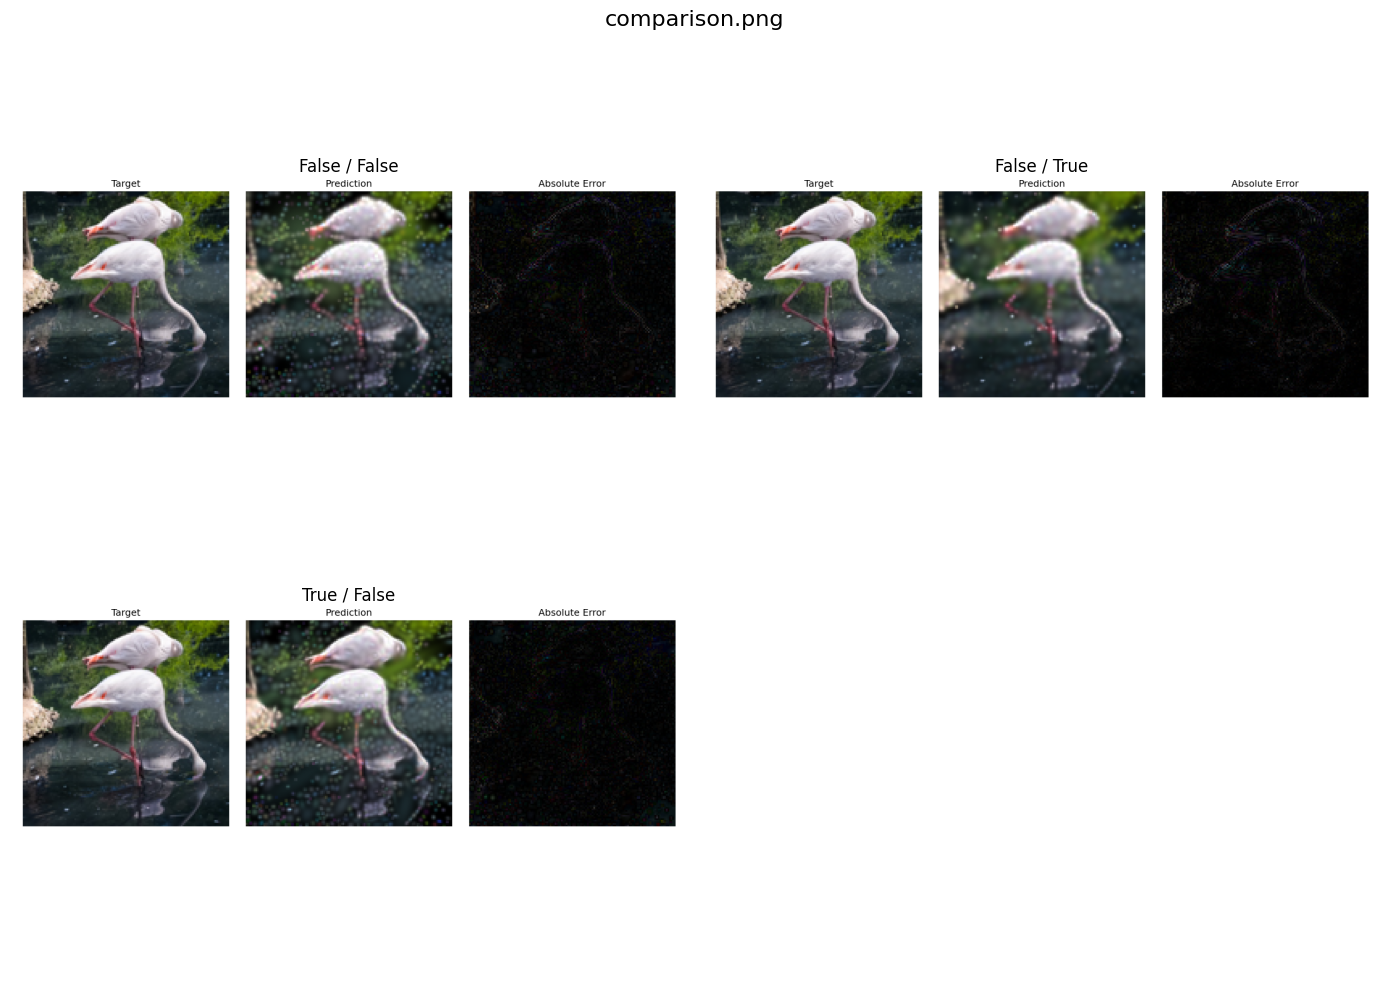

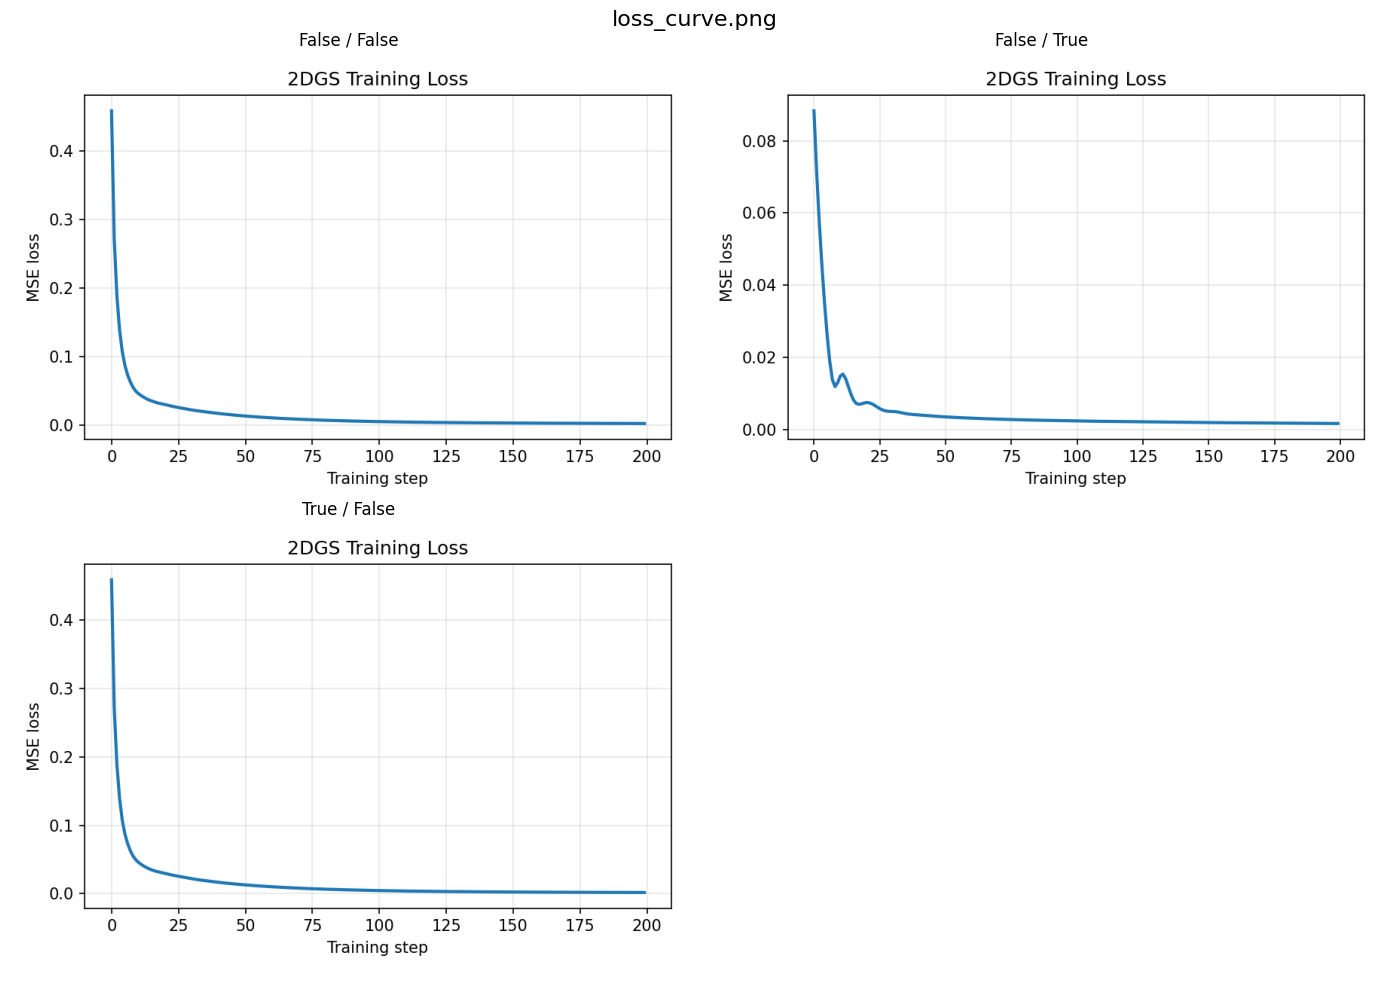

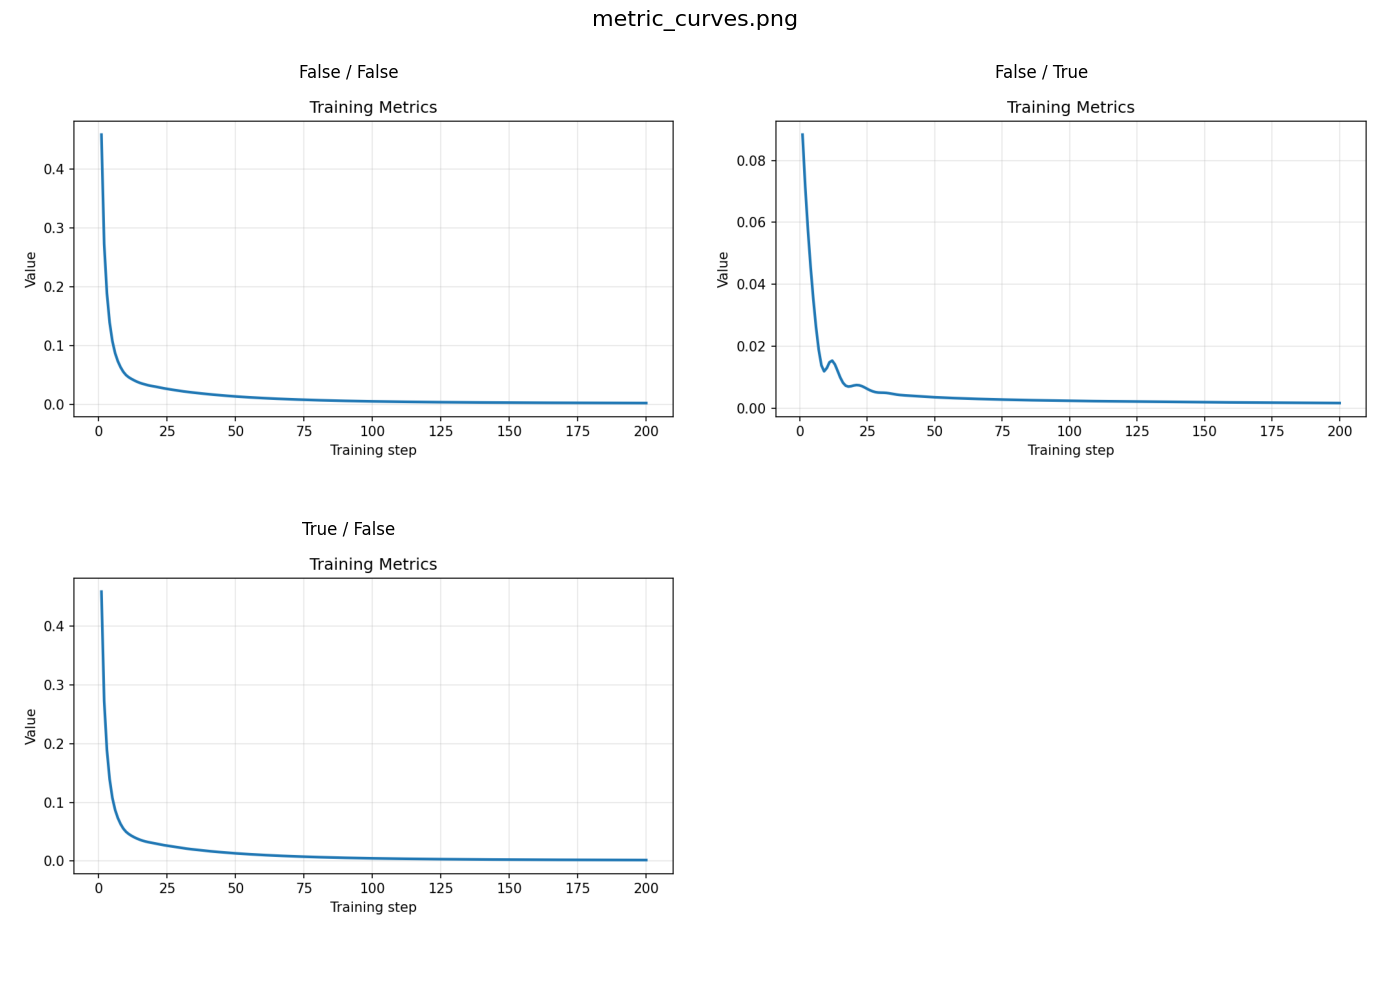

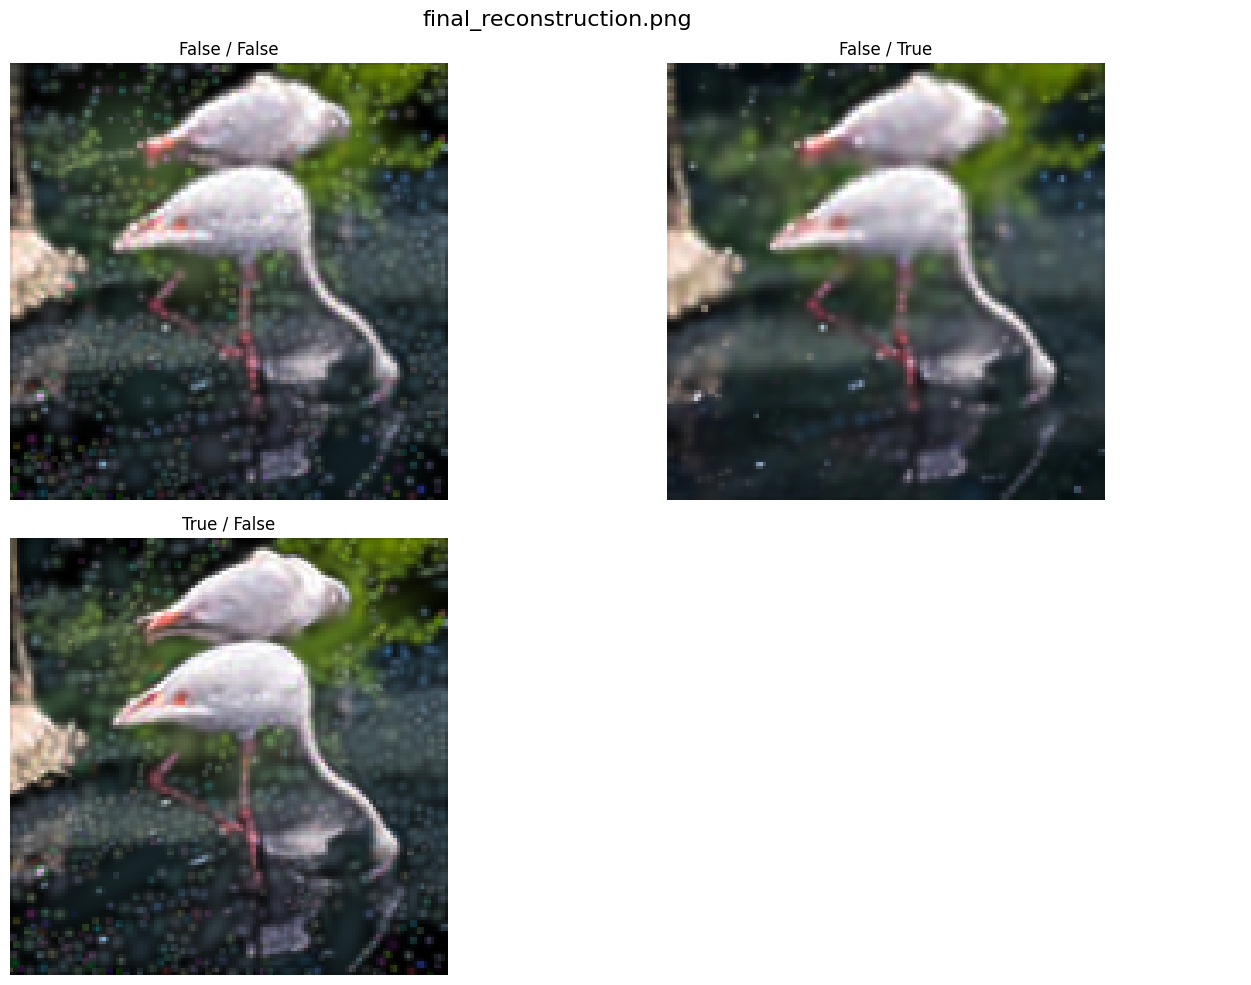

In [5]:
for image_name in IMAGE_NAMES:
    show_image_collection(image_name)
